In [1]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2
import matplotlib.pyplot as plt
from tqdm import tqdm
from tqdm import trange
import sys
import os

current_dir = os.getcwd()
sys.path.append(os.path.dirname(current_dir))
sys.path.append(os.path.dirname(os.path.dirname(current_dir)))
from read_data_package.utils import *
from MYCRT_package.utils import *
from config import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
def T_calculate(X, Y):
    m, n = X.shape[0], Y.shape[0]
    diff_XX = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    mu_FF = np.sum(diff_XX)/(m*(m-1))

    diff_YY = np.linalg.norm(Y[:, None, :] - Y[None, :, :], axis=2)
    mu_GG = np.sum(diff_YY)/(n*(n-1))

    diff_XY = np.linalg.norm(X[:, None, :] - Y[None, :, :], axis=2)
    mu_FG = np.sum(diff_XY)/(m*n)

    mu_DF = np.array([mu_FF, mu_FG])
    mu_DG = np.array([mu_FG, mu_GG])
    return np.linalg.norm(mu_DF - mu_DG)**2, mu_FF, mu_FG, mu_GG

def compute_S(YX):
    m = YX.shape[0]
    D = pdist(YX, metric='euclidean')
    D_mat = squareform(D)
    sum_Xij = np.sum(D)
    Xij = (2 * sum_Xij / (m * (m - 1))) ** 2
    Xijk = 0.0
    for i in range(m-2):
        for j in range(i+1, m-1):
            t = np.sum(D_mat[i,j] * D_mat[i, j+1:])
            t += np.sum(D_mat[i,j+1:] * D_mat[j, j+1:])
            t += np.sum(D_mat[i,j] * D_mat[j, j+1:])
            Xijk += t/3

    Xijk = 6 * Xijk / (m * (m - 1) * (m - 2))
    return Xijk - Xij, Xijk, Xij

def T_star_calculate(X, Y):
    m, n = X.shape[0], Y.shape[0]
    T, *_ = T_calculate(X, Y)
    S1, Xijk, Xij = compute_S(X)
    S2, Yijk, Yij  = compute_S(Y)
    sigma0 = (m*S1+n*S2)/(m+n)
    T_star = m*n/(m+n)*T/(2*sigma0)
    return T_star, S1, S2, Xijk, Xij, Yijk, Yij

def random_split_and_calculate(X, Y, num_iterations=100):
    XY = np.concatenate((X, Y), axis=0)
    m, n = X.shape[0], Y.shape[0]
    T_values = []
    for _ in trange(num_iterations):
        indices = np.random.permutation(m+n)
        X = XY[indices[:m]]
        Y = XY[indices[m:m+n]]
        T, _, _, _ = T_calculate(X, Y)
        T_values.append(T)
    return T_values

In [3]:
call_name = 'Unnamed: 0'
Y_name = 'BRCA1P1'
U_list = ['Basal','Her2','LumA','LumB','Normal']
p = 200
YXz, YXzE, XzU = read_data(call_name, p)
X = YXz.drop(columns= [call_name]).values
Y = YXzE.drop(columns= [call_name]).values
X0 = YXz.drop(columns= [call_name, Y_name]).values
Y0 = YXzE.drop(columns= [call_name, Y_name]).values
U = {}
for u_name, xzu in zip(U_list, XzU):
    U[u_name] = xzu.drop(columns= [call_name]).values

## XZ test

In [4]:
T_star_list = {}
for u_name, z in tqdm(U.items()):
    T_star, *_ = T_star_calculate(X0, z)
    T_star_list[f'In_{u_name}'] = T_star
for u_name, z in tqdm(U.items()):
    T_star, *_ = T_star_calculate(Y0, z)
    T_star_list[f'E_{u_name}'] = T_star
T_star, *_ = T_star_calculate(X0, Y0)
T_star_list[f'In_E'] = T_star

100%|██████████| 5/5 [01:01<00:00, 12.27s/it]


In [5]:
P_list = {name: 1 - chi2.cdf(T_star, 1) for name, T_star in T_star_list.items()}
P_list

{'In_Basal': 0.19739492224460675,
 'In_Her2': 0.13089124080022108,
 'In_LumA': 0.2047390830953788,
 'In_LumB': 0.06192558158078765,
 'In_Normal': 0.7979435932451617,
 'E_Basal': 0.0,
 'E_Her2': 0.0,
 'E_LumA': 0.0,
 'E_LumB': 0.0,
 'E_Normal': 0.0,
 'In_E': 0.0}

## XYZ Asymptotic test

In [6]:
T, mu_FF, mu_FG, mu_GG = T_calculate(X, Y)
T, mu_FF, mu_FG, mu_GG

(4.727435798247889, 18.81262710229758, 17.362839290082224, 15.74248405193236)

In [7]:
T_star, S1, S2, Xijk, Xij, Yijk, Yij = T_star_calculate(X, Y)
T_star, S1, S2, Xijk, Xij, Yijk, Yij

(70.4573099607172,
 11.219933073559787,
 3.1880370415543666,
 365.1348715636612,
 353.9149384901014,
 251.01384116689894,
 247.82580412534458)

In [8]:
p_v = 1 - chi2.cdf(T_star, 1)
p_v

0.0

## XYZ Permutation test

In [9]:
n_num = 100
np.random.seed(24)
T_list = random_split_and_calculate(X, Y, n_num)
T, _, _, _ = T_calculate(X, Y)

100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


0.0


Text(0.5, 1.0, 'T = 4.72744')

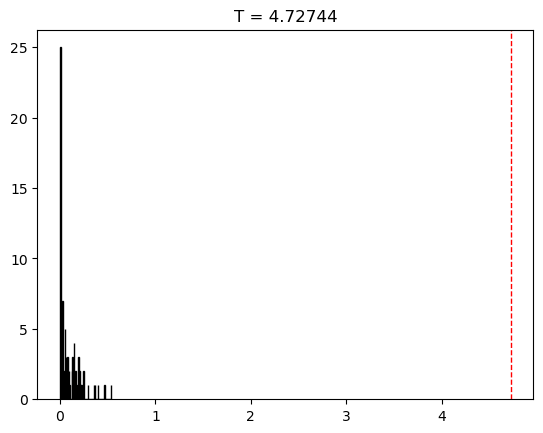

In [10]:
print(np.sum(np.array(T_list)>T)/n_num)
plt.hist(T_list, bins=100, edgecolor='black')
plt.axvline(T, color='red', linestyle='dashed', linewidth=1)
plt.title(f"T = {T:.5f}")